<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/41_Decision_Tree_Own.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV


In [127]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/Social_Network_Ads.csv")

In [128]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [129]:
df.drop(columns=["User ID"], inplace=True)

In [130]:
df.sample(2)

,Gender,Age,EstimatedSalary,Purchased
210,Female,48,96000,1
83,Male,35,88000,0


In [135]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [136]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [138]:
trf=ColumnTransformer([
    ("age_salary",StandardScaler(),["Age","EstimatedSalary"]),
    ("trf3", OneHotEncoder(drop="first", sparse_output=False), ["Gender"])

],remainder="passthrough")

In [139]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [140]:
X_train_trf.shape

(320, 3)

In [141]:
X_train.shape

(320, 3)

In [152]:
def plot_decision_tree(max_depth):
  dt=DecisionTreeClassifier()
  dt.fit(X_train_trf,y_train)
  y_pred=dt.predict(X_test_trf)
  accuracy_score(y_test,y_pred)
  plot_decision_regions(X=X_train_trf, y=y_train.values, clf=dt, legend=2, feature_index=(0, 1), filler_feature_values={2: 0})


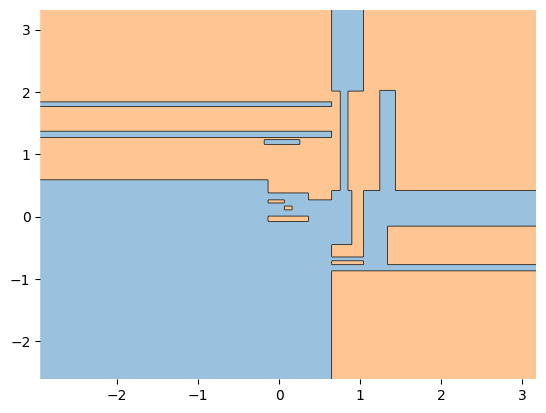

In [153]:
plot_decision_tree(None)

In [173]:
def plot_decision_trees(max_depth):
  dt=DecisionTreeClassifier()
  dt.fit(X_train_trf,y_train)
  y_pred=dt.predict(X_test_trf)
  accuracy_score(y_test,y_pred)

  # Determine the range for the grid based on X_test
  # Use the min/max of the first two features for the grid
  x_min, x_max =X_train_trf[:, 0].min() - 1, X_train_trf[:, 0].max() + 1
  y_min, y_max = X_train_trf[:, 1].min() - 1, X_train_trf[:, 1].max() + 1

  # Create a meshgrid
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

  # Flatten the meshgrid points for prediction
  grid_points = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, 0)]

  # Predict classes for all points in the meshgrid
  Z = dt.predict(grid_points)

  # Reshape the predictions back to the meshgrid shape
  Z = Z.reshape(xx.shape)

  # Plot the contourf and scatter original points
  plt.contourf(xx, yy, Z, alpha=0.5)
  # Correctly pass the first column of X_test for x and the second for y
  plt.scatter(X_test_trf[:, 0], X_test_trf[:, 1], c=y_test, s=20, edgecolor='k')
  plt.title('Decision Boundary of Decision Tree on Test Data')
  plt.xlabel('Scaled Age')
  plt.ylabel('Scaled EstimatedSalary')
  plt.show()

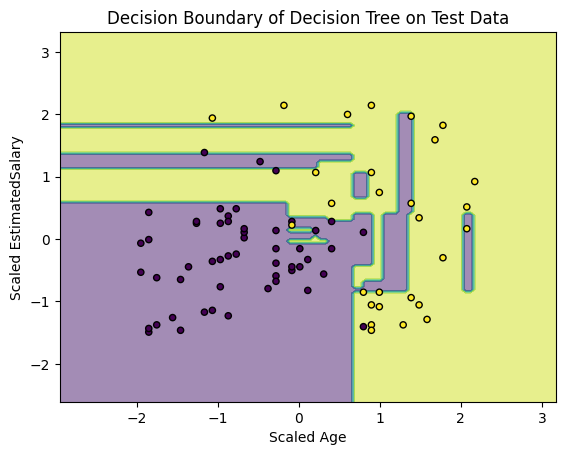

In [174]:
plot_decision_trees(None)

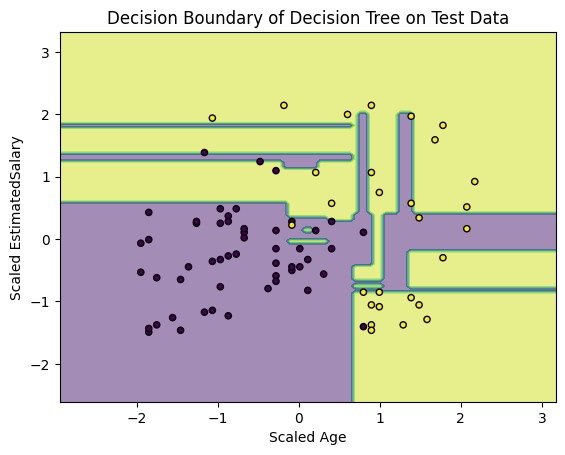

In [183]:
plot_decision_trees(2)

In [177]:
param_grid = {
    'max_depth': [None, 2, 4, 6, 8, 10, 15, 20]
}

In [178]:
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1          # use all cores
)

In [180]:
grid_search.fit(X_train_trf,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 2, 4, 6, 8, 10, 15, 20]},
             scoring='accuracy')

In [181]:
grid_search.best_params_

{'max_depth': 2}

In [182]:
grid_search.best_score_

np.float64(0.9)